# **Import necessary libraries**


In [1]:
!pip install PyWavelets
!pip install imbalanced-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pywt
import joblib
import warnings
warnings.filterwarnings('ignore')

# **Load dataset**


In [2]:
kaggle_df  = pd.read_csv("/content/kaggle_dataset.csv")
company_df = pd.read_csv("/content/company_data.csv")

In [3]:
features = ["Ia","Ib","Ic","Va","Vb","Vc"]

In [4]:
kaggle_df["Fault"] = (kaggle_df["Fault_Type"]).astype(int)
company_df["Fault"] = company_df["Fault_Type"]

In [5]:
kaggle_df.drop(columns=["Fault_Type"], inplace=True)
company_df.drop(columns=["Fault_Type"], inplace=True)

In [6]:
df = pd.concat([kaggle_df, company_df])

In [7]:
df.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault,P_a,Q_a,PF_a,P_b,Q_b,PF_b,P_c,Q_c,PF_c
0,0,0,0,0,-25.966805,-8.276645,30.787902,0.522009,-0.490543,-0.031466,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,0,1,827.929307,65.235107,-14.917177,-0.181270,-0.008740,0.190010,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0,0,0,-26.291415,92.247084,-68.853681,-0.616093,0.276685,0.339408,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0,1,1,849.642844,-273.265642,25.528055,0.027473,-0.338933,0.311460,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0,0,0,-48.676854,95.332992,-49.778235,-0.551966,0.048705,0.503261,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Data Exploration**


In [8]:
kaggle_df.shape

(3930, 11)

In [9]:
company_df.shape

(600, 20)

In [10]:
df.shape

(4530, 20)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4530 entries, 0 to 599
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       4530 non-null   int64  
 1   C       4530 non-null   int64  
 2   B       4530 non-null   int64  
 3   A       4530 non-null   int64  
 4   Ia      4530 non-null   float64
 5   Ib      4530 non-null   float64
 6   Ic      4530 non-null   float64
 7   Va      4530 non-null   float64
 8   Vb      4530 non-null   float64
 9   Vc      4530 non-null   float64
 10  Fault   4530 non-null   int64  
 11  P_a     600 non-null    float64
 12  Q_a     600 non-null    float64
 13  PF_a    600 non-null    float64
 14  P_b     600 non-null    float64
 15  Q_b     600 non-null    float64
 16  PF_b    600 non-null    float64
 17  P_c     600 non-null    float64
 18  Q_c     600 non-null    float64
 19  PF_c    600 non-null    float64
dtypes: float64(15), int64(5)
memory usage: 743.2 KB


In [12]:
df.describe()


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc,Fault,P_a,Q_a,PF_a,P_b,Q_b,PF_b,P_c,Q_c,PF_c
count,4530.000000,4530.000000,4530.00000,4530.000000,4530.000000,4530.000000,4530.000000,4530.000000,4530.000000,4530.000000,4530.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,0.387859,0.356733,0.49404,0.496689,46.796251,6.321602,60.693903,0.832921,0.837131,0.843949,2.510375,1667.146774,662.276208,0.290798,1656.560187,694.505048,0.289150,1637.597104,686.420236,0.287077
std,0.487316,0.479088,0.50002,0.500044,444.630741,420.142740,356.705997,2.160155,2.167872,2.165774,1.938102,98.772180,37.627935,0.013755,98.313163,39.166436,0.013075,90.904322,39.463240,0.013720
min,0.000000,0.000000,0.00000,0.000000,-883.542316,-900.526951,-883.357762,-0.620712,-0.608016,-0.612709,0.000000,1502.573468,595.472130,0.267236,1495.917868,627.628455,0.265206,1476.238490,616.350189,0.265547
25%,0.000000,0.000000,0.00000,0.000000,-69.736857,-87.332441,-53.434560,-0.042812,-0.068532,-0.157751,1.000000,1579.336057,629.299361,0.278628,1571.111092,662.767930,0.278271,1559.383502,656.504313,0.274913
50%,0.000000,0.000000,0.00000,0.000000,31.358747,38.671745,14.957850,0.020415,0.021575,0.035553,2.000000,1668.732081,664.353275,0.290739,1657.351097,693.415900,0.289439,1636.472498,685.885795,0.285869
75%,1.000000,1.000000,1.00000,1.000000,287.954304,266.539981,263.909447,0.357608,0.374968,0.352059,5.000000,1749.896253,695.240245,0.303654,1745.274974,725.785969,0.299763,1715.085210,721.282791,0.298692
max,1.000000,1.000000,1.00000,1.000000,885.546976,889.788111,901.101164,6.644506,6.649681,6.642766,5.000000,1835.588452,727.662973,0.314312,1827.421141,766.248547,0.311973,1802.463680,753.070031,0.312190


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
company_only_cols = ["P_a","Q_a","PF_a","P_b"	,"Q_b",	"PF_b"	,"P_c",	"Q_c"	,"PF_c"]
df[company_only_cols] = df[company_only_cols].fillna(0)

In [15]:
df.isna().sum()

,0
G,0
C,0
B,0
A,0
Ia,0
Ib,0
Ic,0
Va,0
Vb,0
Vc,0


In [16]:
df = df.drop(columns=["G","C","B","A"], errors='ignore')
df.head()

,Ia,Ib,Ic,Va,Vb,Vc,Fault,P_a,Q_a,PF_a,P_b,Q_b,PF_b,P_c,Q_c,PF_c
0,-25.966805,-8.276645,30.787902,0.522009,-0.490543,-0.031466,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,827.929307,65.235107,-14.917177,-0.181270,-0.008740,0.190010,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-26.291415,92.247084,-68.853681,-0.616093,0.276685,0.339408,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,849.642844,-273.265642,25.528055,0.027473,-0.338933,0.311460,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-48.676854,95.332992,-49.778235,-0.551966,0.048705,0.503261,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Feature Engineering**

In [17]:
eps = 1e-9

# 1. Magnitude Features
df["I_mag"] = np.sqrt(df["Ia"]**2 + df["Ib"]**2 + df["Ic"]**2)
df["V_mag"] = np.sqrt(df["Va"]**2 + df["Vb"]**2 + df["Vc"]**2)

# 2. Zero Sequence Components
df["I_zero"] = (df["Ia"] + df["Ib"] + df["Ic"]) / 3
df["V_zero"] = (df["Va"] + df["Vb"] + df["Vc"]) / 3

# 3. Ratio Features
df["Ia_ratio"] = df["Ia"] / (df["I_mag"] + eps)
df["Ib_ratio"] = df["Ib"] / (df["I_mag"] + eps)
df["Ic_ratio"] = df["Ic"] / (df["I_mag"] + eps)

df["Va_ratio"] = df["Va"] / (df["V_mag"] + eps)
df["Vb_ratio"] = df["Vb"] / (df["V_mag"] + eps)
df["Vc_ratio"] = df["Vc"] / (df["V_mag"] + eps)

# 4. Unbalance Features
df["I_unbalance"] = (
    df[["Ia","Ib","Ic"]].max(axis=1) - df[["Ia","Ib","Ic"]].min(axis=1)
) / (df["I_mag"] + eps)

df["V_unbalance"] = (
    df[["Va","Vb","Vc"]].max(axis=1) - df[["Va","Vb","Vc"]].min(axis=1)
) / (df["V_mag"] + eps)

# 5. Sign Features
df["I_zero_sign"] = np.sign(df["I_zero"])
df["V_zero_sign"] = np.sign(df["V_zero"])

# 6. Additional Power Features
df["I_neg"] = np.sqrt(
    np.maximum((df["Ia"]**2 + df["Ib"]**2 + df["Ic"]**2 -
               df["Ia"]*df["Ib"] - df["Ib"]*df["Ic"] - df["Ic"]*df["Ia"]) / 3, 0)
)

df["S_total"] = df["Va"]*df["Ia"] + df["Vb"]*df["Ib"] + df["Vc"]*df["Ic"]

print(f" Original features: 6")
print(f" Engineered features: {df.shape[1] - 1}")

 Original features: 6
 Engineered features: 31


In [18]:
df.head()

,Ia,Ib,Ic,Va,Vb,Vc,Fault,P_a,Q_a,PF_a,...,Ic_ratio,Va_ratio,Vb_ratio,Vc_ratio,I_unbalance,V_unbalance,I_zero_sign,V_zero_sign,I_neg,S_total
0,-25.966805,-8.276645,30.787902,0.522009,-0.490543,-0.031466,5,0.0,0.0,0.0,...,0.748773,0.728027,-0.684143,-0.043884,1.380296,1.412169,-1.0,1.0,29.040424,-10.463609
1,827.929307,65.235107,-14.917177,-0.181270,-0.008740,0.190010,3,0.0,0.0,0.0,...,-0.017959,-0.689888,-0.033264,0.723152,1.014708,1.413039,1.0,0.0,465.209098,-153.483434
2,-26.291415,92.247084,-68.853681,-0.616093,0.276685,0.339408,5,0.0,0.0,0.0,...,-0.583138,-0.815090,0.366054,0.449036,1.364399,1.264126,-1.0,0.0,83.482911,18.351846
3,849.642844,-273.265642,25.528055,0.027473,-0.338933,0.311460,2,0.0,0.0,0.0,...,0.028591,0.059578,-0.735011,0.675433,1.257638,1.410444,1.0,0.0,581.573488,123.911803
4,-48.676854,95.332992,-49.778235,-0.551966,0.048705,0.503261,5,0.0,0.0,0.0,...,-0.421673,-0.737391,0.065066,0.672325,1.229240,1.409716,-1.0,0.0,83.463881,6.459666


In [19]:
df['Fault'].value_counts()

,count
Fault,
5,1182
0,1089
1,625
2,567
3,565
4,502


# **Outliers Detection**


In [20]:
def outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print(" Outlier using IQR")

numeric_columns = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
outliers_summary = {}

for col in numeric_columns:
    outliers, lower, upper = outliers_iqr(df, col)
    outliers_summary[col] = {
        'count': len(outliers),
        'lower_bound': lower,
        'upper_bound': upper
    }

    print(f"\n{col}:")
    print(f"  outliers: {len(outliers)}")
    print(f" Lower bound: {lower:.2f}")
    print(f" Upper bound: {upper:.2f}")

 Outlier using IQR

Ia:
  outliers: 820
 Lower bound: -606.27
 Upper bound: 824.49

Ib:
  outliers: 753
 Lower bound: -618.14
 Upper bound: 797.35

Ic:
  outliers: 615
 Lower bound: -529.45
 Upper bound: 739.93

Va:
  outliers: 600
 Lower bound: -0.64
 Upper bound: 0.96

Vb:
  outliers: 600
 Lower bound: -0.73
 Upper bound: 1.04

Vc:
  outliers: 600
 Lower bound: -0.92
 Upper bound: 1.12


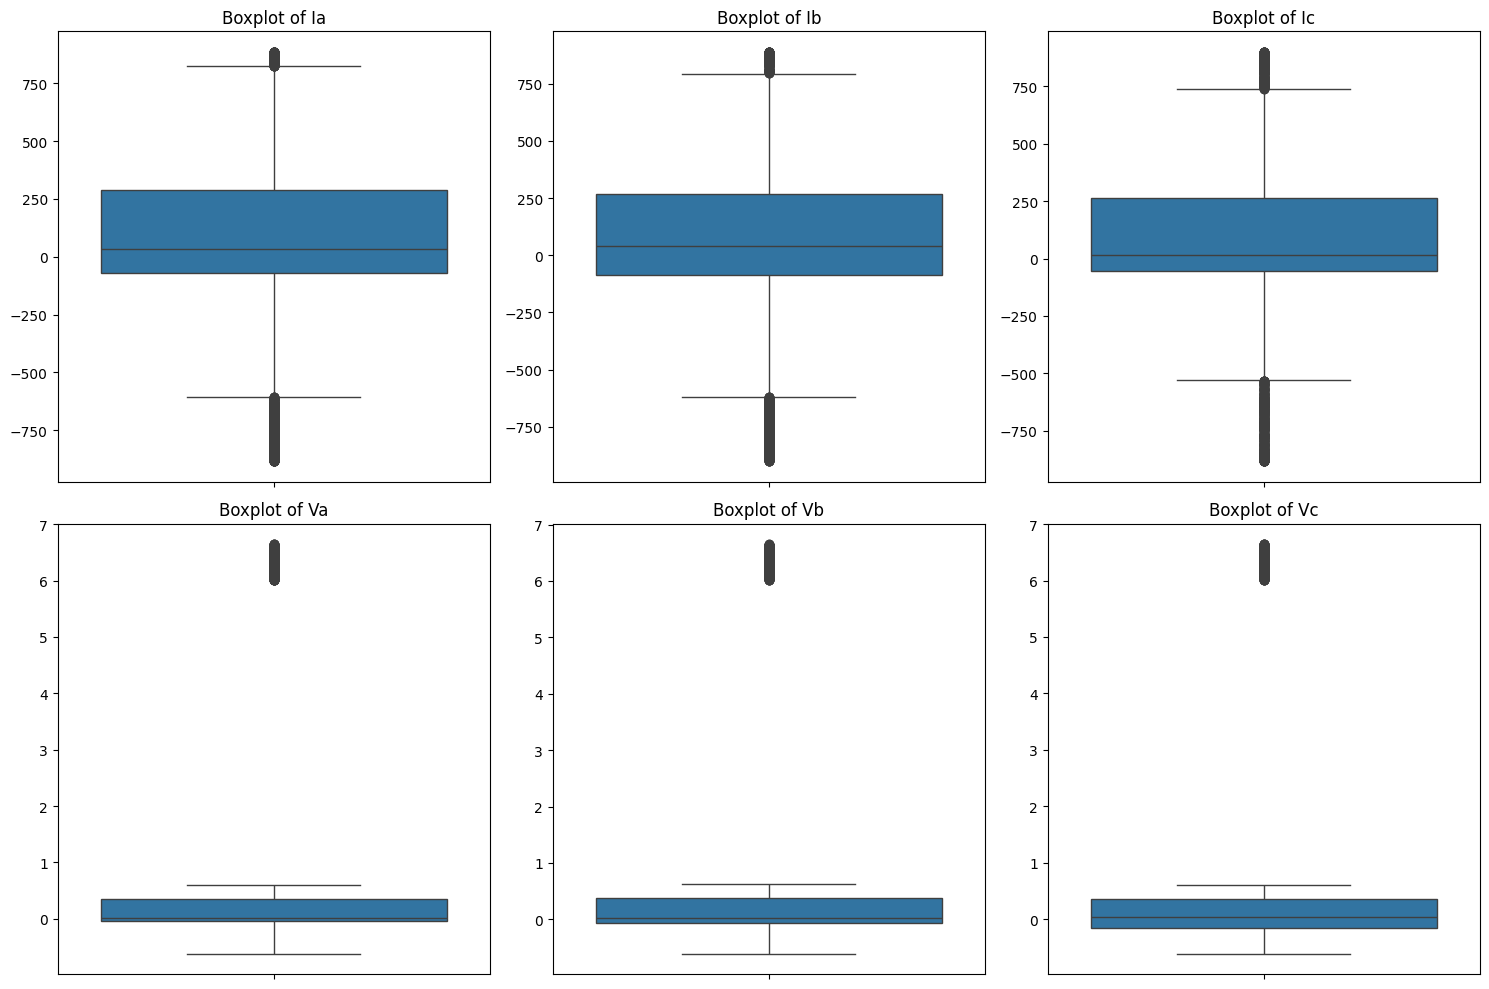

In [21]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

# **Model Creation**


In [22]:

X = df[features]
y = df["Fault"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
feature_cols = X_train.columns.tolist()
joblib.dump(feature_cols, "my_feature_columns.joblib")

['my_feature_columns.joblib']

# **Scalling**

In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
joblib.dump(scaler, "my_scaler.joblib")
print("Scaler saved!")

Scaler saved!


# **SMOTE**

In [26]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {5: 945, 0: 871, 1: 500, 2: 454, 3: 452, 4: 402}
After SMOTE: {0: 945, 2: 945, 5: 945, 1: 945, 3: 945, 4: 945}


# **Random Forest Model**

In [27]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=5,
    max_features=0.7,
    random_state=42
)

rf.fit(X_train_res, y_train_res)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f" Random Forest Accuracy: {accuracy:.2f}")
print(" Classification Report Reduced Random Forest:")
print(classification_report(y_test, y_pred, digits=3))

joblib.dump(rf,"Randomforest_model.joblib")

 Random Forest Accuracy: 0.87
 Classification Report Reduced Random Forest:
              precision    recall  f1-score   support

           0      0.849     0.619     0.716       218
           1      0.536     0.768     0.632       125
           2      0.956     0.956     0.956       113
           3      0.950     1.000     0.974       113
           4      1.000     0.980     0.990       100
           5      0.996     1.000     0.998       237

    accuracy                          0.869       906
   macro avg      0.881     0.887     0.878       906
weighted avg      0.887     0.869     0.870       906



['Randomforest_model.joblib']

<Axes: title={'center': 'RandomForest Confusion Matrix'}>

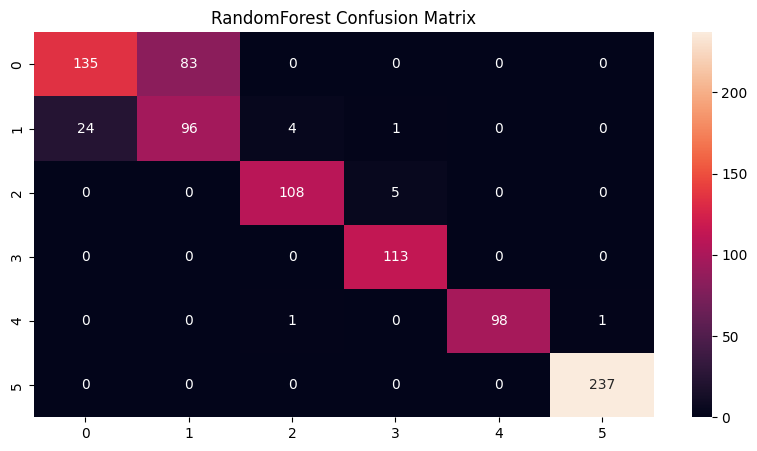

In [28]:
rf_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,5))
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("RandomForest Confusion Matrix")
sns.heatmap(rf_cm,annot=True,fmt='d')

# **XG Boosting Model**

In [29]:
xgb = XGBClassifier(
    n_estimators=80,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1.5,
    min_child_weight=2,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_res, y_train_res)
y_pred_XG = xgb.predict(X_test)
print(classification_report(y_test, y_pred_XG, zero_division=0))
print("Accuracy:", accuracy_score(y_test, y_pred))

joblib.dump(xgb, "XG_model.joblib")

              precision    recall  f1-score   support

           0       0.98      0.55      0.70       218
           1       0.55      0.86      0.67       125
           2       0.89      0.92      0.90       113
           3       0.86      1.00      0.93       113
           4       0.99      0.97      0.98       100
           5       0.98      1.00      0.99       237

    accuracy                           0.86       906
   macro avg       0.88      0.88      0.86       906
weighted avg       0.90      0.86      0.86       906

Accuracy: 0.8686534216335541


['XG_model.joblib']

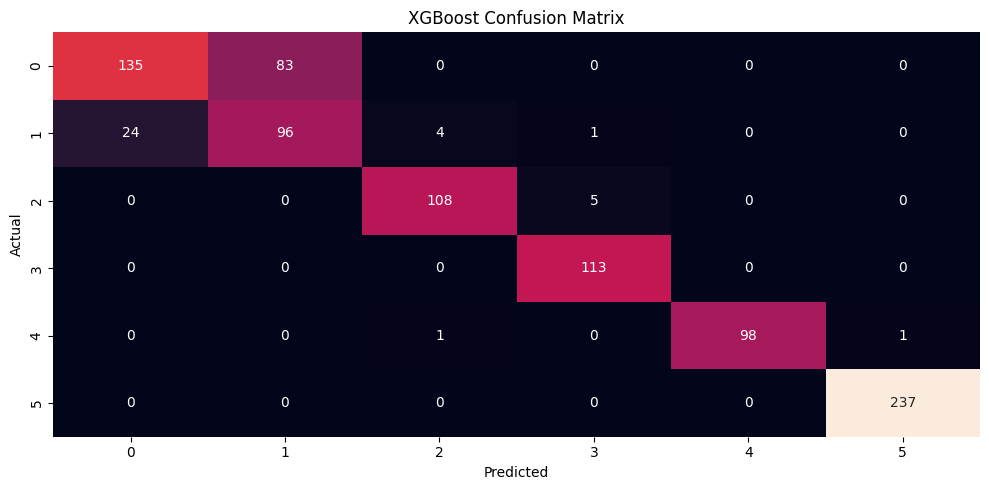

In [30]:
XG_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,5))
sns.heatmap(XG_cm, annot=True, fmt='d', cbar=False)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

# **Suppot Vector Machine Model**

In [31]:
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_res, y_train_res)
svm_pred = svm_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, digits=3))
joblib.dump(svm_model, "SVM_model.joblib")

Accuracy: 0.7792494481236203
              precision    recall  f1-score   support

           0      0.910     0.555     0.689       218
           1      0.552     0.632     0.590       125
           2      0.723     0.717     0.720       113
           3      0.678     0.876     0.764       113
           4      0.795     0.890     0.840       100
           5      0.912     1.000     0.954       237

    accuracy                          0.779       906
   macro avg      0.762     0.778     0.759       906
weighted avg      0.796     0.779     0.775       906



['SVM_model.joblib']

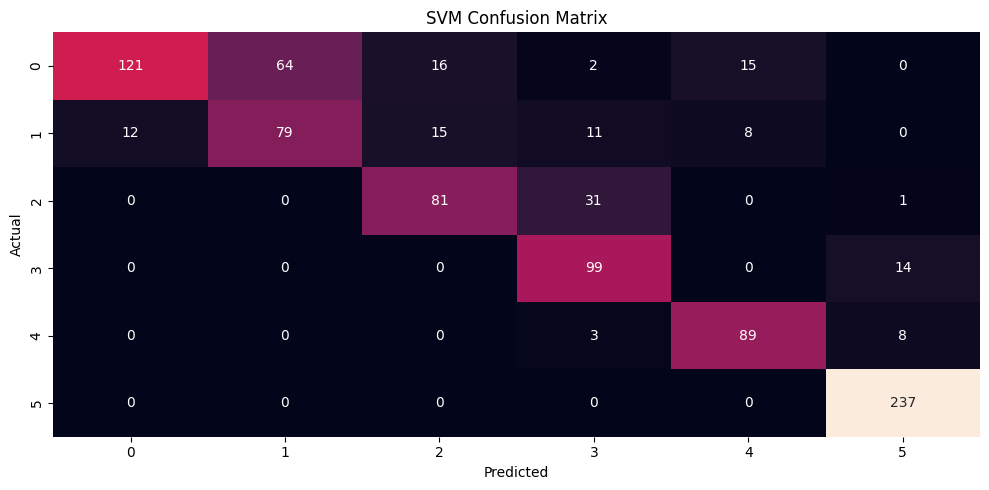

In [32]:
SVM_cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(10,5))
sns.heatmap(SVM_cm, annot=True, fmt='d', cbar=False)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

# MLP (ANN) model

In [33]:
num_classes = len(np.unique(y_train_res))
print("Number of classes:", num_classes)

model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train_res.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Number of classes: 6


In [34]:
history = model.fit(
    X_train_res, y_train_res,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3264 - loss: 1.5365 - val_accuracy: 0.2840 - val_loss: 1.3233
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6888 - loss: 0.8027 - val_accuracy: 0.8078 - val_loss: 0.6865
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7504 - loss: 0.6260 - val_accuracy: 0.8607 - val_loss: 0.5124
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7579 - loss: 0.5765 - val_accuracy: 0.8995 - val_loss: 0.5520
Epoch 5/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7694 - loss: 0.5330 - val_accuracy: 0.9206 - val_loss: 0.3665
Epoch 6/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7772 - loss: 0.5092 - val_accuracy: 0.9242 - val_loss: 0.3850
Epoch 7/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8037 - loss: 0.4572 - val_accuracy: 0.9330 - val_loss: 0.2999
Epoch 8/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7935 - loss: 0.4584 - val_accuracy

In [35]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.8675496578216553


In [36]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.56      0.69       218
           1       0.53      0.87      0.66       125
           2       0.97      0.96      0.96       113
           3       0.95      1.00      0.97       113
           4       1.00      0.98      0.99       100
           5       0.99      1.00      1.00       237

    accuracy                           0.87       906
   macro avg       0.89      0.89      0.88       906
weighted avg       0.90      0.87      0.87       906



In [38]:
joblib.dump(model, "MLP_model.joblib")

['MLP_model.joblib']

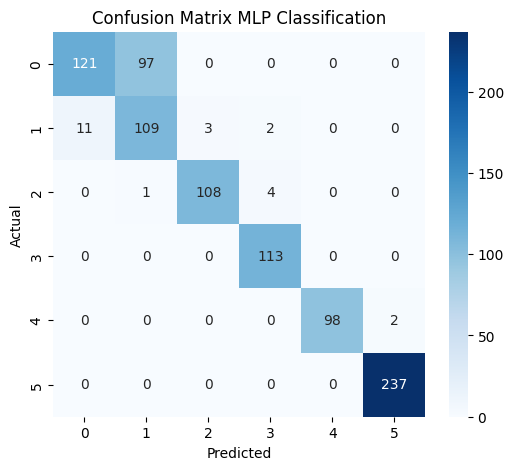

In [39]:
cm= confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix MLP Classification")
plt.show()


# **wavelet Transformission**

In [40]:
# def extract_wavelet_features(row):
#     signal = row[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']].values

#     coeffs = pywt.dwt(signal, 'db4')
#     cA, cD = coeffs

#     features = {
#         'cA_mean': np.mean(cA),
#         'cA_std': np.std(cA),
#         'cA_energy': np.sum(np.square(cA)),
#         'cD_mean': np.mean(cD),
#         'cD_std': np.std(cD),
#         'cD_energy': np.sum(np.square(cD))
#     }
#     return pd.Series(features)

# wavelet_features_df = df.apply(extract_wavelet_features, axis=1)

# X = wavelet_features_df
# y = df['Fault']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# sm = SMOTE(random_state=42)
# X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

# # Random Forest
# rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
# rf_model.fit(X_train_res, y_train_res)
# rf_pred = rf_model.predict(X_test_scaled)
# print("Random Forest Wavelet")
# print(classification_report(y_test, rf_pred, digits=3))

# # XGBoost
# xgb_model = XGBClassifier(n_estimators=80, learning_rate=0.05, max_depth=3, random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='mlogloss')
# xgb_model.fit(X_train_res, y_train_res)
# xgb_pred = xgb_model.predict(X_test_scaled)
# print("XGBoost Wavelet")
# print(classification_report(y_test, xgb_pred, digits=3))

# #SVM
# svm_model = SVC(kernel='rbf', random_state=42)
# svm_model.fit(X_train_res, y_train_res)
# svm_pred = svm_model.predict(X_test_scaled)
# print("SVM Wavelet")
# print(classification_report(y_test, svm_pred, digits=3))